In [ ]:
import sys; sys.path.insert(0, '../Sparse_Cholesky')

In [65]:
from cholesky import *
from ordering import *
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
torch.set_default_dtype(torch.float64)

# Parameters
N = 100  # Number of grid points
L = 1.0  # Length of the domain [0, 1]
rho = 20 # Sparsity factor defined by ln(N/epsilon)
x = torch.linspace(0, L, N+1)[:-1]  # Equidistant grid points
x_ten = x.unsqueeze(1)
Perm, lengths = maximin(x_ten) # Calculating MaxMin Ordering
sparsity = sparsity_pattern(x_ten[Perm], lengths, rho) # Calculating the sparsity pattern
nonzeros_indices = non_zeros(N, sparsity) # Calculating the non zero indices
print(nonzeros_indices.shape[1]/5050)
dx = x[1] - x[0]  # Grid spacing
num_newton_iter = 5 # Number of classical Newton iterations for Data generation
num_realizations = 1200  # Number of realizations
Factor = 50
num_training = num_realizations * num_newton_iter-1200  # Number of training samples
num_folds = 5  # For cross-validation
lambda_reg = 0.00001 # Regularizer for the Newton-Iteration


# Gaussian Process class with learnable nugget
class GaussianProcess(nn.Module):
    def __init__(self, length_scale=1.0, nugget_init=1e-6, nu=3 / 2):
        super(GaussianProcess, self).__init__()
        self.length_scale = nn.Parameter(torch.ones(N) * length_scale)
        # self.length_scale = nn.Parameter(torch.ones(1) * length_scale)
        # self.nugget = nn.Parameter(torch.tensor(nugget_init))
        self.nugget = torch.tensor(nugget_init)
        self.nu = nu

    def matern_kernel(self, X1, X2):
        # Compute pairwise Euclidean distance between points in scaled X1 and X2
        X1_scaled = X1 * self.length_scale
        X2_scaled = X2 * self.length_scale
        pairwise_dists = torch.cdist(X1_scaled, X2_scaled, p=2)

        if self.nu == 3 / 2:
            scale = torch.sqrt(torch.tensor(3.0)) * pairwise_dists
            K = (1 + scale) * torch.exp(-scale)
        else:
            raise ValueError("Only nu=3/2 is supported.")
        return K

    def fit(self, X_train, y_train):
        # Kernel matrices with learnable nugget
        K_train = self.matern_kernel(X_train, X_train) + torch.eye(X_train.shape[0]) * self.nugget
        # L = torch.linalg.cholesky(K_train)
        # alpha_train = torch.linalg.solve_triangular(L, y_train, upper=False)
        alpha_train = torch.linalg.solve(K_train, y_train)
        self.alpha_train = alpha_train
        self.X_train = X_train

    def forward(self, X_val):
        K_val_train = self.matern_kernel(X_val, self.X_train)
        y_pred_val = K_val_train @ self.alpha_train
        return y_pred_val

    # def forward(self, X_train, y_train, X_val):
    #     # Kernel matrices with learnable nugget
    #     K_train = self.matern_kernel(X_train, X_train) + torch.eye(X_train.shape[0]) * self.nugget
    #     # L = torch.linalg.cholesky(K_train)
    #     # alpha_train = torch.linalg.solve_triangular(L, y_train, upper=False)
    #     alpha_train = torch.linalg.solve(K_train, y_train)
    #
    #     K_val_train = self.matern_kernel(X_val, X_train)
    #     y_pred_val = K_val_train @ alpha_train
    #     return y_pred_val
    

# Generate the covariance matrix using the Matérn kernel
def generate_covariance_matrix(kernel_func, x, length_scale):
    return kernel_func(x.unsqueeze(1), x.unsqueeze(1), length_scale)

# Generate f and u based on GP(0, K)
def generate_f_u_from_gp(num_realizations, N, kernel_func, length_scale, x):
    K = kernel_func(x.unsqueeze(1), x.unsqueeze(1), length_scale)
    K = K + 1e-3 * torch.eye(K.shape[0])
    L = torch.linalg.cholesky(K)
    f_realizations = torch.randn(num_realizations, N)
    u_realizations = torch.randn(num_realizations, N)
    f_realizations = (L @ f_realizations.T).T
    u_realizations = (L @ u_realizations.T).T
    # mean = torch.zeros(N)
    # f_realizations = torch.stack([torch.distributions.MultivariateNormal(mean, K).rsample() for _ in range(num_realizations)])
    # u_realizations = torch.stack([torch.distributions.MultivariateNormal(mean, K).rsample() for _ in range(num_realizations)])
    return f_realizations, u_realizations


# Periodic Laplacian matrix (finite difference approximation)
def laplacian_matrix(N, dx):
    main_diag = -2 * torch.ones(N)
    off_diag = torch.ones(N - 1)
    A = torch.diag(main_diag) + torch.diag(off_diag, 1) + torch.diag(off_diag, -1)
    A[0, -1] = 1
    A[-1, 0] = 1
    A /= dx ** 2
    return A


# Dirichlet Laplacian matrix (finite difference approximation)
def laplacian_matrix_dir(N, dx):
    main_diag = -2 * torch.ones(N)
    off_diag = torch.ones(N)
    A = torch.diag(main_diag) + torch.diag(off_diag, 1) + torch.diag(off_diag, -1)
    A /= dx ** 2
    return A


def residual(f, u, N, dx):
    A_laplace = laplacian_matrix(N, dx)
    P = f + A_laplace @ u - Factor * u ** 3
    return P


# Invert matrix using Cholesky decomposition
def cholesky_inverse(A):
    L = torch.linalg.cholesky(A + 1e-8 * torch.eye(len(A)), upper=False)
    L_inv = torch.inverse(L)
    # A_inv = L_inv.T @ L_inv  # A_inv = (L_inv.T) * (L_inv)
    return L_inv


# Solves the equation via classical Newton iteration. v_solutions contains the GP(0,K) generated data u_0 and the all of the Newton iterations to max_inter.
def classical_newton_method(f, v0, A_laplace, max_iter, learning_rate):
    v_n = v0.clone()

    # Initialize a matrix to store the solution at each iteration
    solutions_matrix = torch.zeros((max_iter+1, v0.numel()))  # numel() gives the number of elements in v0

    # Store the current solution in the matrix
    solutions_matrix[0, :] = v_n.view(-1)  # Store the flattened solution

    for i in range(max_iter):
        # Solve the Newton iteration
        # delta_v = solve_reg_system(f, v_n, A_laplace, lambda_reg)
        delta_v = solve_system_linalg(f,v_n,A_laplace)
        # Update rule: v_{n+1} = v_n + delta_v
        v_n = v_n + learning_rate*delta_v.squeeze()

        # Store the current solution in the matrix
        solutions_matrix[i+1, :] = v_n.view(-1)  # Store the flattened solution

        # print(f"Iteration {i + 1}, Update: {delta_v.mean().item()}")

    return solutions_matrix

# Solves the equation via classical Newton iteration. v_solutions contains the GP(0,K) generated data u_0 and the all of the Newton iterations to max_inter.

def classic_newton_method(f, v0, A_laplace, max_iter, learning_rate):
    v_n = v0.clone()

    for i in range(max_iter):
        # Solve the Newton iteration
        delta_v = solve_system_linalg(f,v_n,A_laplace)
        # Update rule: v_{n+1} = v_n + delta_v
        v_n = v_n + learning_rate*delta_v.squeeze()

    return v_n


def newton_line_search(f, v0, A_laplace, max_iter, c1, beta):
    v_n = v0.clone()

    for i in range(max_iter):
        
        # Solve the Newton iteration
        delta_v = solve_system_linalg(f,v_n,A_laplace)
        P = -A_laplace + torch.diag(3 * Factor * v_n ** 2)
        F_n = - A_laplace @ v_n + Factor * v_n ** 3 - f     
        d = P.T @ F_n
        alpha = 1  # Initial step size
        v_trial = v_n + alpha * delta_v 
        F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f       # Evaluate F at current guess

        # for iteration in range(3):  # Limit to a maximum of 3 iterations
        #     if torch.norm(F_n_delta)**2 <= torch.norm(F_n)**2 + 2 * c1 * alpha * torch.dot(d, delta_v):
        #         break  # Exit the loop if the condition is met
        #     alpha *= beta  # Reduce step size if condition is not met
        
        while torch.norm(F_n_delta)**2 >= torch.norm(F_n)**2 + 2* c1 * alpha * torch.dot(d, delta_v):
            alpha *= beta  # Reduce step size
            v_trial = v_n + alpha * delta_v 
            F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f      
            
        # Update rule: v_{n+1} = v_n + alpha * delta_v
        v_n = v_n + alpha * delta_v

    return v_n



def classical_newton_method_reg(f, v0, A_laplace, max_iter, lambda_reg, learning_rate):
    v_n = v0.clone()

    # Initialize a matrix to store the solution at each iteration
    solutions_matrix = torch.zeros((max_iter+1, v0.numel()))  # numel() gives the number of elements in v0

    # Store the current solution in the matrix
    solutions_matrix[0, :] = v_n.view(-1)  # Store the flattened solution

    for i in range(max_iter):
        # Solve the Newton iteration
        delta_v = solve_reg_system(f, v_n, A_laplace, lambda_reg)
        # delta_v = solve_system_linalg(f,v_n,A_laplace)
        # Update rule: v_{n+1} = v_n + delta_v
        v_n = v_n + learning_rate * delta_v.squeeze()

        # Store the current solution in the matrix
        solutions_matrix[i+1, :] = v_n.view(-1)  # Store the flattened solution

        # print(f"Iteration {i + 1}, Update: {delta_v.mean().item()}")

    return solutions_matrix


def classical_newton_method_min(f, v0, A_laplace, max_iter):
    v_n = v0.clone()

    for i in range(max_iter):
        # Solve the Newton iteration
        delta_v = solve_system_min(f, v_n, A_laplace)
        # Update rule: v_{n+1} = v_n + delta_v
        v_n = v_n + delta_v.squeeze()

    return v_n


def inverse_map(u_realizations, N, lambda_reg):
    M = u_realizations.shape[0]

    # List to store the flattened inverse matrices
    flattened_inverses = []

    # Loop over each realization
    for i in range(M):
        u_i = u_realizations[i, :]  # ith function

        # Construct the matrix A_i = -A_laplace + diag(3 * u_i^2)
        A = -A_laplace + torch.diag(3 * Factor * u_i ** 2)
        A_T = A.T 
        A_i = lambda_reg * torch.eye(A.size(0)) + A_T @ A

        # Compute the inverse using Cholesky decomposition
        try:
            L_inv = cholesky_inverse(A_i)
        except RuntimeError:
            print(f"Matrix {i} is not positive definite. Skipping.")
            continue
        
        # Flatten the inverse matrix and store it
        flattened_inverses.append(L_inv.flatten())

    # Convert list of flattened inverses to a tensor
    flattened_inverses = torch.stack(flattened_inverses)

    return flattened_inverses



def inverse_map_min(u_realizations, N):
    M = u_realizations.shape[0]

    # List to store the flattened inverse matrices
    flattened_inverses = []

    # Loop over each realization
    for i in range(M):
        u_i = u_realizations[i, :]  # ith function

        # Construct the matrix A_i = -A_laplace + diag(3 * u_i^2)
        A = -A_laplace + torch.diag(3 * Factor * u_i ** 2)
        A_T = A.T 
        
        tau_two_prime_u = 6 * Factor * u_i
        b = f + A_laplace @ u_i - Factor * u_i ** 3
        A = -A_laplace + torch.diag(3 * Factor * u_i ** 2)
        abs_a = torch.abs(tau_two_prime_u * b)
        ones = torch.ones_like(abs_a)
        I = torch.diag(ones)*torch.mean(abs_a)
        # A_i = lambda_reg * torch.eye(A.size(0)) + A_T @ A
        A_i = I + A_T @ A
        # Compute the inverse using Cholesky decomposition
        try:
            L_inv = cholesky_inverse(A_i)
        except RuntimeError:
            print(f"Matrix {i} is not positive definite. Skipping.")
            continue
        
        lower_elements = L_inv[torch.tril(torch.ones_like(L_inv, dtype=bool))]
        
        # Store the flatten inverses
        flattened_inverses.append(lower_elements)

    # Convert list of flattened inverses to a tensor
    flattened_inverses = torch.stack(flattened_inverses)

    return flattened_inverses


def inverse_map_tri(u_realizations, N, lambda_reg):
    M = u_realizations.shape[0]

    # List to store the flattened inverse matrices
    flattened_inverses = []

    # Loop over each realization
    for i in range(M):
        u_i = u_realizations[i, :]  # ith function

        # Construct the matrix A_i = -A_laplace + diag(3 * u_i^2)
        A = -A_laplace + torch.diag(3 * Factor * u_i ** 2)
        A_T = A.T 
        A_i = lambda_reg * torch.eye(A.size(0)) + A_T @ A
        lower_triangular_vectors = []

        # Compute the inverse using Cholesky decomposition
        try:
            L_inv = cholesky_inverse(A_i)
        except RuntimeError:
            print(f"Matrix {i} is not positive definite. Skipping.")
            continue
        
        lower_elements = L_inv[torch.tril(torch.ones_like(L_inv, dtype=bool))]
        
        # Store the flatten inverses
        flattened_inverses.append(lower_elements)

    # Convert list of flattened inverses to a tensor
    flattened_inverses = torch.stack(flattened_inverses)

    return flattened_inverses


def inverse_map_sparse_cholesky(u_realizations, lambda_reg, Perm, sparsity):
    M = u_realizations.shape[0]

    # List to store the flattened inverse matrices
    flattened_inverses = []

    # Loop over each realization
    for i in range(M):
        u_i = u_realizations[i, :]  # ith function

        # Construct the matrix A_i = -A_laplace + diag(3 * u_i^2)
        A = -A_laplace + torch.diag(3 * Factor * u_i ** 2)
        A_T = A.T 
        A_i = lambda_reg * torch.eye(A.size(0)) + A_T @ A 
        
        # Compute the inverse using Cholesky decomposition
        U_sparse = sparse_cholesky(A_i, Perm, sparsity)
        sparse_elements = U_sparse._values()
        
        if i % 3000 == 0:
            print(sparse_elements.shape)
            print(sparse_elements)
        
        # Store the flatten inverses
        flattened_inverses.append(sparse_elements)

    # Convert list of flattened inverses to a tensor
    flattened_inverses = torch.stack(flattened_inverses)

    return flattened_inverses
    



# Solve the system A v = b for each realization
def solve_system_linalg(f, u, A_laplace):
    A = -A_laplace + torch.diag(3 * Factor * u ** 2)
    b = f + A_laplace @ u - Factor * u ** 3
    # Mat = cholesky_inverse(A)
    # v = Mat @ b 
    v = torch.linalg.solve(A, b)
    return v

# Solve the system A v = b for each realization
def solve_system_cholesky(f, u, A_laplace):
    A = -A_laplace + torch.diag(3 * Factor * u ** 2)
    b = f + A_laplace @ u - Factor * u ** 3
    Mat = cholesky_inverse(A)
    v = Mat @ b 
    # v = torch.linalg.solve(A, b)
    return v

# Solve the regularized system (lambda I +A'A) v = A' b for each realization
def solve_reg_system(f, u, A_laplace, lambda_reg):
    tau_prime_u = 3 * Factor * u ** 2
    A = -A_laplace + torch.diag(tau_prime_u)
    b = f + A_laplace @ u - Factor * u ** 3
    A_T = A.T 
    # lambda I is the regularization term, and A'A is the normal equation term
    A_reg = lambda_reg * torch.eye(A.size(0)) + A_T @ A
    # Right-hand side for the system
    rhs = A_T @ b
    # Solve the system (lambda I + A'A) v = A'b
    v = torch.linalg.solve(A_reg, rhs)
    
    return v


# Solve the regularized system (lambda I +A'A) v = A' b for each realization
def solve_system_min(f, u, A_laplace):
    tau_prime_u = 3 * Factor * u ** 2
    tau_two_prime_u = 6 * Factor * u
    A = -A_laplace + torch.diag(tau_prime_u)
    b = f + A_laplace @ u - Factor * u ** 3
    # Take the absolute value of `a`
    abs_a = torch.abs(tau_two_prime_u * b)
    # Create a tensor with the same shape as `a`, filled with 1s
    # ones = torch.ones_like(abs_a)
    # Compute element-wise maximum between `abs_a` and 1
    # min = torch.maximum(abs_a, ones)
    # I = torch.diag(abs_a)
    ones = torch.ones_like(abs_a)
    I = torch.diag(ones)*torch.mean(abs_a)
    A_T = A.T 
    # lambda I is the regularization term, and A'A is the normal equation term
    A_reg = I + A_T @ A
    # Right-hand side for the system
    rhs = A_T @ b 
    # Solve the system (lambda I + A'A) v = A'b
    v = torch.linalg.solve(A_reg, rhs)
    
    return v


# Cross-validation with GP kernel and alpha optimization using KFold
def cross_validation_loss(model, X, y, num_folds=5):
    kf = KFold(n_splits=num_folds)
    l2_losses = 0

    for train_index, val_index in kf.split(X):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        # GP prediction on validation data
        model.fit(X_train, y_train)
        y_pred_val = model(X_val)

        # Compute the relative L2 loss
        l2_loss = torch.mean(torch.norm(y_val - y_pred_val, dim=1) / torch.norm(y_val, dim=1))
        l2_losses += l2_loss

    # Return the mean loss across all folds
    return l2_losses / num_folds


# Train step
def train_step(model, X, y, optimizer):
    optimizer.zero_grad()
    loss_value = cross_validation_loss(model, X, y, num_folds)
    loss_value.backward()
    optimizer.step()
    return loss_value


def periodic_kernel(X1, X2, length_scale=1, period=1):
    pairwise_dists = torch.cdist(X1, X2, p=2)
    sine_term = torch.sin(torch.pi * pairwise_dists / period)
    K = torch.exp(-2 * sine_term ** 2 / length_scale ** 2)
    return K


# Define the kernel function
def matern_kernel(X1, X2, length_scale):
    pairwise_dists = torch.cdist(X1, X2, p=2)
    scale = torch.sqrt(torch.tensor(3.0)) * pairwise_dists / length_scale
    K = (1 + scale) * torch.exp(-scale)
    return K

0.4312871287128713


In [66]:
# # Instantiate the GP model and Adam optimizer
optimizer = [None] * 2
gp_model = [None] * 2

# Laplacian matrix for the grid
A_laplace = laplacian_matrix(N, dx)


# Generate data for f and u based on GP(0, K)
f_realizations, u_realizations = generate_f_u_from_gp(num_realizations, N, periodic_kernel, length_scale=0.2, x=x)

# Solve the system for each realization with up to max_iter Newton iterations.
v_solutions = torch.cat([classical_newton_method(f_realizations[j], u_realizations[j], A_laplace, max_iter=num_newton_iter, learning_rate = 1) for j in range(num_realizations)], dim=0)

f = torch.repeat_interleave(f_realizations, repeats=num_newton_iter, dim=0)
X_data =v_solutions

# y_data_groundtruth = inverse_map_tri(v_solutions, N, lambda_reg)
y_data = inverse_map_sparse_cholesky(v_solutions, lambda_reg, Perm, sparsity)

torch.Size([2178])
tensor([4.0813e-05, 3.6489e-05, 5.4729e-05,  ..., 1.0620e-03, 1.5345e-03,
        1.7245e-03])
torch.Size([2178])
tensor([4.0789e-05, 3.6458e-05, 5.4723e-05,  ..., 8.9952e-04, 8.9304e-04,
        1.2871e-03])
torch.Size([2178])
tensor([4.0815e-05, 3.6482e-05, 5.4689e-05,  ..., 7.0878e-04, 3.0423e-04,
        6.1477e-04])


In [67]:
# Train the model using Adam and cross-validation
num_steps = 150  # Number of optimization steps

# Define a matrix containing the lambda values and the corresponding cross-validation error
alpha_error_matrix = torch.zeros((2, num_steps))

# Instantiate the GP model and Adam optimizer
gp_model[0] = GaussianProcess(length_scale=1.0)
optimizer[0] = optim.Adam(gp_model[0].parameters(), lr=0.01)

for step in range(num_steps):
    loss_value = train_step(gp_model[0], X_data[:num_training], y_data[:num_training], optimizer[0])

    # Step the schedulerloss_value
    # scheduler.step(loss_value)

    # Predict on the test set
    X_train = X_data[:num_training]
    y_train = y_data[:num_training]
    X_test = X_data[num_training:]
    y_pred_test = y_data[num_training:]
    

    with torch.no_grad():
        gp_model[0].fit(X_train, y_train)
        y_pred_test_pca = gp_model[0](X_test)


    # Calculate relative L2 error
    rl2error = torch.mean(torch.norm(y_pred_test_pca - y_pred_test, dim=1) / torch.norm(y_pred_test, dim=1)).item()
    # r2error_A_inv = torch.mean(torch.norm(y_pred_test_pca - y_pred_test, dim=1) / torch.norm(y_pred_test, dim=1)).item()
    l2error = torch.mean(torch.norm(y_pred_test_pca - y_pred_test, dim=1)).item()
    current_lr = optimizer[0].param_groups[0]['lr']
    alpha_error_matrix[0, step] = rl2error
    
    
    print(f"Step {step}, Loss: {loss_value.item()}, Rel. L2 err: {rl2error}, L2 err: {l2error}, Learning Rate: {current_lr}, Lambda = {lambda_reg}")

Step 0, Loss: 0.2641663168119113, Rel. L2 err: 0.26156760973562004, L2 err: 0.0027000650523841697, Learning Rate: 0.01, Lambda = 1e-05
Step 1, Loss: 0.26257457462980677, Rel. L2 err: 0.25985782169513616, L2 err: 0.0026794554490230217, Learning Rate: 0.01, Lambda = 1e-05
Step 2, Loss: 0.2609701987586111, Rel. L2 err: 0.2581397554346869, L2 err: 0.002658767755144098, Learning Rate: 0.01, Lambda = 1e-05
Step 3, Loss: 0.2593528840583975, Rel. L2 err: 0.2564123052357925, L2 err: 0.002637987268321746, Learning Rate: 0.01, Lambda = 1e-05
Step 4, Loss: 0.2577227457567625, Rel. L2 err: 0.25467538285741625, L2 err: 0.0026171128164179454, Learning Rate: 0.01, Lambda = 1e-05
Step 5, Loss: 0.2560803767953792, Rel. L2 err: 0.2529307348679488, L2 err: 0.002596167427704101, Learning Rate: 0.01, Lambda = 1e-05
Step 6, Loss: 0.254425197855359, Rel. L2 err: 0.2511800875493583, L2 err: 0.0025751738030487235, Learning Rate: 0.01, Lambda = 1e-05
Step 7, Loss: 0.25275624850491357, Rel. L2 err: 0.249423754317

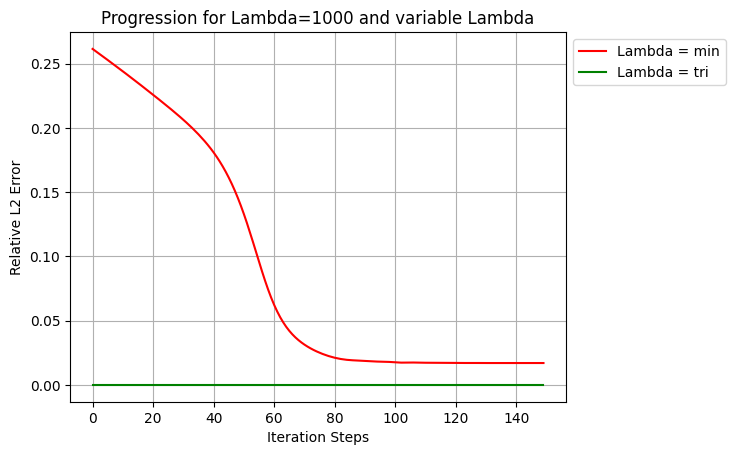

In [68]:
# # After training, save each model's state_dict with a unique filename
# torch.save(gp_model[0].state_dict(), f"gaussian_process_model_min.pth")
# torch.save(gp_model[1].state_dict(), f"gaussian_process_model_tri.pth")

# # After training, save each model's state_dict with a unique filename
# torch.save(gp_model[0].state_dict(), f"gaussian_process_model_lambda_L_inv.pth")
# torch.save(gp_model[1].state_dict(), f"gaussian_process_model_lambda_A_inv.pth")


# Plotting
def plot_results(matrix, num_steps):
    # Convert matrix to numpy for easier plotting
    result_numpy = matrix.numpy()

    # Define a list of colors for each alpha (7 values, 7 colors)
    colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']  # Red, Green, Blue, Cyan, Magenta, Yellow, Black

    # Plot for each alpha
    plt.plot(range(num_steps), result_numpy[0, :], label=f'Lambda = min', color=colors[0])
    plt.plot(range(num_steps), result_numpy[1, :], label=f'Lambda = tri', color=colors[1])


    # Add labels and legend
    plt.xlabel('Iteration Steps')
    plt.ylabel('Relative L2 Error')
    plt.title('Progression for Lambda=1000 and variable Lambda')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True)
    plt.show()

# Call the plot function
plot_results(alpha_error_matrix, num_steps)

In [69]:
# Solves the equation via Gradient decent iteration. v_solutions contains the GP(0,K) generated data u_0 and the all of the Newton iterations to max_inter.

def gradient_decent_method(f, v0, A_laplace, max_iter, alpha):
    v_n = v0.clone()

    for i in range(max_iter):
        v_diag = 3 * Factor * v_n ** 2
        A = -A_laplace + torch.diag(v_diag)
        b = f + A_laplace @ v_n - Factor * v_n ** 3
        A_T = A.T 
        direction = A_T @ b
        delta_v = alpha * direction
        # Update rule: v_{n+1} = v_n + delta_v
        v_n = v_n + delta_v
        
    return v_n


def deep_newton_method_line_search(model, f, v0, A_laplace, max_iter, c1, beta, learning_rate):
    v_n = v0.clone()

    for i in range(max_iter):
        # Prepare the inputs for GP prediction
        X_train = v_n.unsqueeze(0)  # No need to cat if there's only one tensor
        tmp = model.forward(X_train)
        
        # Create an empty matrix of desired size
        L_inv = torch.zeros((N, N), dtype = tmp.dtype)
        
        # Create a mask for the lower triangular part
        mask = torch.tril(torch.ones((N, N), dtype = torch.bool))
        
        # Fill in the lower triangular part using the vector
        L_inv[mask] = tmp
        
        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = L_inv.T @ L_inv

        # Compute F and the Gradient of F at v_n
        F_n = - A_laplace @ v_n + Factor * v_n ** 3 - f     
        P = -A_laplace + torch.diag(3 * Factor * v_n ** 2)        
    
        # Compute the right-hand side of the linear system
        d = P.T @ F_n
        
        # Solve the system A_inv @ rhs to find delta_v
        delta_v = A_inv @ d
        
        alpha = learning_rate  # Initial step size
        v_trial = v_n - alpha * delta_v 
        F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f       # Evaluate F at current guess

        
        while torch.norm(F_n_delta)**2 > torch.norm(F_n)**2 + 2* c1 * alpha * torch.dot(d, delta_v):
            alpha *= beta  # Reduce step size
            v_trial = v_n - alpha * delta_v 
            F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f      
            
        # Update rule: v_{n+1} = v_n + alpha * delta_v
        v_n = v_n - alpha * delta_v

    return v_n



def deep_newton_method_sparse_cholesky(model, N, f, v0, A_laplace, max_iter, c1, beta, learning_rate):
    v_n = v0.clone()

    for i in range(max_iter):
        # Prepare the inputs for GP prediction
        X_train = v_n.unsqueeze(0)  # No need to cat if there's only one tensor
        U_sparse = model.forward(X_train)
        
        # Convert sparse tensor to dense for validation
        nonzeros_indices = non_zeros(N, sparsity) # Calculating the non zero indices
        U_sparse_flat = U_sparse.flatten()  # Converts shape (1, k) to (k,)
        sparse_tensor = torch.sparse_coo_tensor(nonzeros_indices, U_sparse_flat, size=(N, N))
        U_dense = sparse_tensor.to_dense()
        invPerm = torch.argsort(Perm)
        
        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = (U_dense @ U_dense.T)[invPerm][:, invPerm]

        # Compute F and the Gradient of F at v_n
        F_n = - A_laplace @ v_n + Factor * v_n ** 3 - f     
        P = -A_laplace + torch.diag(3 * Factor * v_n ** 2)        
    
        # Compute the right-hand side of the linear system
        d = P.T @ F_n
        
        # Solve the system A_inv @ rhs to find delta_v
        delta_v = A_inv @ d
        
        alpha = learning_rate  # Initial step size
        v_trial = v_n - alpha * delta_v 
        F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f       # Evaluate F at current guess

        
        while torch.norm(F_n_delta)**2 > torch.norm(F_n)**2 + 2* c1 * alpha * torch.dot(d, delta_v):
            alpha *= beta  # Reduce step size
            v_trial = v_n - alpha * delta_v 
            F_n_delta = - A_laplace @ v_trial + Factor * v_trial ** 3 - f      
            
        # Update rule: v_{n+1} = v_n + alpha * delta_v
        v_n = v_n - alpha * delta_v

    return v_n





def deep_newton_method_line_search_with_cubic(model, f, v0, A_laplace, max_iter, c1, learning_rate, epsilon=1e-8):
    v_n = v0.clone()
    alpha_max = learning_rate  # Maximum initial step size

    for i in range(max_iter):
        # Prepare the inputs for GP prediction
        X_train = v_n.unsqueeze(0)
        tmp = model.forward(X_train)
        
        # Create an empty matrix of desired size
        N = A_laplace.shape[0]
        L_inv = torch.zeros((N, N), dtype=tmp.dtype)
        mask = torch.tril(torch.ones((N, N), dtype=torch.bool))
        L_inv[mask] = tmp
        
        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        A_inv = L_inv.T @ L_inv

        # Compute F and the Gradient of F at v_n
        F_n = -A_laplace @ v_n + Factor * v_n ** 3 - f
        P = -A_laplace + torch.diag(3 * Factor * v_n ** 2)
        d = P.T @ F_n
        delta_v = A_inv @ d

        # Initial step size and function evaluations
        alpha = alpha_max
        v_trial = v_n - alpha * delta_v
        F_n_delta = -A_laplace @ v_trial + Factor * v_trial ** 3 - f
        
        # Store initial values for cubic interpolation
        phi_0 = torch.norm(F_n) ** 2
        phi_prime_0 = 2 * torch.dot(d, delta_v)
        phi_alpha = torch.norm(F_n_delta) ** 2
        
        # Backtracking using cubic interpolation
        alpha_prev = 0
        phi_prev = phi_0
        while phi_alpha > phi_0 + c1 * alpha * phi_prime_0:
            # Perform cubic interpolation
            if alpha_prev > 0:
                # Fit cubic polynomial
                d1 = phi_prime_0 + (phi_alpha - phi_prev) / (alpha - alpha_prev)
                d2 = (phi_alpha - phi_prev) / (alpha - alpha_prev) ** 2 - phi_prime_0 / (alpha - alpha_prev)
                if abs(d2) > epsilon:
                    alpha_cubic = alpha - d1 / (2 * d2)
                else:
                    alpha_cubic = alpha / 2  # Fallback to halving step
                alpha_cubic = max(0.1 * alpha, min(alpha_cubic, 0.5 * alpha))  # Ensure bounded step
            else:
                # Use quadratic interpolation for the first iteration
                alpha_cubic = -phi_prime_0 / (2 * (phi_alpha - phi_0 - phi_prime_0))

            # Update trial step
            alpha_prev = alpha
            phi_prev = phi_alpha
            alpha = alpha_cubic
            v_trial = v_n - alpha * delta_v
            F_n_delta = -A_laplace @ v_trial + Factor * v_trial ** 3 - f
            phi_alpha = torch.norm(F_n_delta) ** 2
        
        # Update rule: v_{n+1} = v_n - alpha * delta_v
        v_n = v_trial

    return v_n




def deep_newton_method(model, f, v0, max_iter, learning_rate):
    v_n = v0.clone()

    for i in range(max_iter):
        # Prepare the inputs for GP prediction
        X_train = v_n.unsqueeze(0)  # No need to cat if there's only one tensor
        tmp = model.forward(X_train)
            
        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        tau_prime_v = 3 * Factor * v_n ** 2
        A = -A_laplace + torch.diag(tau_prime_v)
        A_T = A.T
        
        L_inv = tmp.reshape(N, N)
            
        # Compute the right-hand side of the linear system
        v = residual(f, v_n, N, dx)
        rhs = A_T @ v
        A_inv = L_inv.T @ L_inv
        
        # Solve the system A_inv @ rhs to find delta_v
        delta_v = A_inv @ rhs
        
        # Update rule: v_{n+1} = v_n + delta_v
        v_n = v_n + learning_rate * delta_v.squeeze()  # Ensure delta_v is the correct shape

    return v_n


def deep_newton_method_tri(model, f, v0, max_iter, learning_rate):
    v_n = v0.clone()

    for i in range(max_iter):
        # Prepare the inputs for GP prediction
        X_train = v_n.unsqueeze(0)  # No need to cat if there's only one tensor
        tmp = model.forward(X_train)
        
        # Construct matrix A and compute A_inv (assumed to be learned by the model)
        tau_prime_v = 3 * Factor * v_n ** 2
        A = -A_laplace + torch.diag(tau_prime_v)
        A_T = A.T
        
        # Create an empty matrix of desired size
        L_inv = torch.zeros((N, N), dtype = tmp.dtype)
        
        # Create a mask for the lower triangular part
        mask = torch.tril(torch.ones((N, N), dtype = torch.bool))
        
        # Fill in the lower triangular part using the vector
        L_inv[mask] = tmp

        # Compute the right-hand side of the linear system
        v = residual(f, v_n, N, dx)
        rhs = A_T @ v
        A_inv = L_inv.T @ L_inv
        
        # Solve the system A_inv @ rhs to find delta_v
        delta_v = A_inv @ rhs
        
        # Update rule: v_{n+1} = v_n + delta_v
        v_n = v_n + learning_rate * delta_v.squeeze()  # Ensure delta_v is the correct shape

    return v_n


In [71]:

# Generating Solutions using the GP sampled data
num_test_data = 20

f_realizations, u_realizations = generate_f_u_from_gp(num_test_data, N, periodic_kernel, length_scale=0.2, x=x)
v_vals2 = u_realizations
f_vals1 = torch.cat([(-A_laplace @ u_realizations[i, :] + Factor * u_realizations[i, :] ** 3).unsqueeze(0)
                     for i in range(u_realizations.size(0))], dim=0)


v_solutions = v_vals2[:, ::1]
f_vals2 = f_vals1[:, ::1]
u0 = torch.zeros_like(v_solutions[0])  # Initial guess v0


# Initialize a variable to accumulate the relative errors
relative_error_sum = 0.0
error_sum = 0.0

# Loop through each realization
for j in range(num_test_data):
    
    # v_predict = deep_newton_method_line_search_with_cubic(gp_model[0],  f_vals2[j,:], u0, A_laplace, max_iter=200, c1 = 1e-4, learning_rate = 1, epsilon=1e-8)

    # v_predict = deep_newton_method_line_search(gp_model[0], f_vals2[j,:], u0, A_laplace, max_iter = 300, c1 = 1e-4, beta = 0.3, learning_rate = 1)
    
    v_predict = deep_newton_method_sparse_cholesky(gp_model[0], N, f_vals2[j,:], u0, A_laplace, max_iter=1000, c1 = 1e-4, beta = 0.3, learning_rate = 1)

        # Calculate the relative L2 error for the current realization
    rl2error = (torch.norm(v_solutions[j, :] - v_predict) / torch.norm(v_solutions[j, :]))
    l2error = torch.norm(v_solutions[j, :] - v_predict) 
    
    print(f"{j}, Total Rel. L2 err: {rl2error}, Total L2 err: {l2error}")
    
    # Calculate the squared relative L2 error for the current realization
    rl2error = rl2error**2
    l2error = l2error**2 
    
    # Accumulate the error
    relative_error_sum += rl2error.item()
    error_sum += l2error.item()
    
# Calculate the mean relative error by dividing by the number of realizations
mean_relative_error = relative_error_sum / num_test_data
mean_error = error_sum / num_test_data

# Take the square root
sqrt_mean_relative_error = mean_relative_error ** 0.5
sqrt_mean_error = mean_error ** 0.5

print(f"Total Rel. L2 err: {mean_relative_error}, Total L2 err: {mean_error}, Lambda = {lambda_reg}")
print(f"Total Rel. L2 err: {mean_relative_error ** 4}, Total L2 err: {mean_error}, Lambda = {lambda_reg}")

0, Total Rel. L2 err: 0.02890587440759538, Total L2 err: 0.27711527418058196
1, Total Rel. L2 err: 0.026280716989313734, Total L2 err: 0.2180763526345497
2, Total Rel. L2 err: 0.11024656286027253, Total L2 err: 0.9050968003747062
3, Total Rel. L2 err: 0.016861535763139857, Total L2 err: 0.19810066018685593
4, Total Rel. L2 err: 7.39291569143219e-05, Total L2 err: 0.0008097205642679643
5, Total Rel. L2 err: 0.3136869629038883, Total L2 err: 2.667106015493431
6, Total Rel. L2 err: 0.02947993921569041, Total L2 err: 0.25870147683729544
7, Total Rel. L2 err: 0.021712260804871923, Total L2 err: 0.2905655779663384
8, Total Rel. L2 err: 0.1527038208157357, Total L2 err: 1.1283358056589805
9, Total Rel. L2 err: 0.0005940277609663648, Total L2 err: 0.006472260884287336
10, Total Rel. L2 err: 0.0005676643096178127, Total L2 err: 0.008084403462547338
11, Total Rel. L2 err: 0.008674604401914612, Total L2 err: 0.0793435735998059
12, Total Rel. L2 err: 0.1806703842522486, Total L2 err: 1.74912635911